In [21]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import corner
import emcee
import scipy
import random
import sys
import time
import neuralop
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm)

<module 'exp_pybamm' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/NO/../exp_pybamm.py'>

In [22]:
from neuralop.models import FNO

In [23]:
def gen_data_NO(batches):
    I = np.zeros((batches,1,1000))
    V = np.zeros((batches,1,1000))
    for i in trange(batches):
        _, _, I[i,0,:], V[i,0,:] = exp_pybamm.get_values()
    return I, V

In [24]:
#I_gen,V_gen = gen_data_NO(100)


In [25]:
#I = np.load('data_NO/I.npz')['arr_0']
#V = np.load('data_NO/V.npz')['arr_0']

In [26]:


# np.savez('data_NO/I.npz',np.vstack((I,I_gen)))
# np.savez('data_NO/V.npz',np.vstack((V,V_gen)))

In [27]:
I = np.load('data_NO/I.npz')['arr_0']
V = np.load('data_NO/V.npz')['arr_0']



test_size = 0.1
I_test = I[0:int(test_size * len(I)),:,:]; V_test = V[0:int(test_size * len(I)),:,:]
I_train = I[int(test_size * len(I)):,:,:]; V_train = V[int(test_size * len(I)):,:,:]

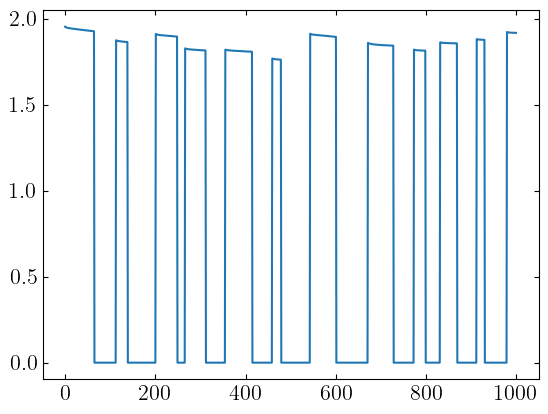

In [28]:
n = 14
plt.plot(I[n,0,:] * V[n,0,:])

In [29]:
from neuralop.models import FNO 
import torch
import torch.nn as nn

# Define the model
model = FNO(
    n_modes=(16,),         
    hidden_channels=32, 
    in_channels=1,      
    out_channels=1,     
)

In [30]:
# from torch.utils.data import DataLoader, TensorDataset

# N, T = 1024, 64

# u = np.zeros((N, T,1))
# y = np.zeros((N, T,1))
# for i in trange(N):
#     w = random.uniform(0.5, 2.0)
#     u[i,:,0] = np.sin(w * np.linspace(0, 3.14, T))
#     y[i,:,0] = w*np.cos(w * np.linspace(0, 3.14, T))


# print(u.shape, y.shape  )

# dataset = TensorDataset(torch.tensor(u, dtype=torch.float32), 
#                         torch.tensor(y, dtype=torch.float32))

# loader = DataLoader(dataset, batch_size=32, shuffle=True)

# u_batch, y_batch = next(iter(loader))
# print(u_batch.shape)  # should be [32, 64, 1]


In [31]:
from torch.utils.data import DataLoader, TensorDataset


dataset = TensorDataset(torch.tensor(I, dtype=torch.float32), 
                        torch.tensor(V, dtype=torch.float32))

loader = DataLoader(dataset, batch_size=32, shuffle=True)

u_batch, y_batch = next(iter(loader))
print(u_batch.shape)  # should be [32, 64, 1]


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.HuberLoss()



torch.Size([32, 1, 1000])


In [32]:

# epochs = 50
# tol = 2.5e-4
# for epoch in range(epochs):
#     nb = 0 
#     loss_sum = 0
#     start_b = time.perf_counter()
#     for u_batch, y_batch in loader:  # u_batch: [B, T, 1]
#         y_pred = model(u_batch)
#         loss = loss_fn(y_pred, y_batch)
#         loss_sum += loss.item()
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         nb += 1
#     end_b = time.perf_counter()
#     ETA = (end_b-start_b)*(epochs-epoch-1)
#     if loss_sum / nb < tol:
#         print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
#         break
#     print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    

In [33]:
# model = MyModel()
# loss_fn = nn.HuberLoss()

# x = x.requires_grad_(True)
# u_pred = model(x)

# # --- Data loss ---
# data_loss = loss_fn(u_pred, u_true)

# # --- Physics loss ---
# du_dx = torch.autograd.grad(
#     u_pred,
#     x,
#     grad_outputs=torch.ones_like(u_pred),
#     create_graph=True
# )[0]

# physics_residual = du_dx + u_pred
# physics_loss = torch.mean(physics_residual**2)

# # --- Total loss ---
# lambda_phys = 0.1
# loss = data_loss + lambda_phys * physics_loss

In [34]:
def training(epochs = 50, tol = 2.5e-4, loader = loader, model = model, optimizer = optimizer, loss_fn = loss_fn):
    history = {'loss': []}
    lambda_phys = 10
    for epoch in range(epochs):
        nb = 0 
        loss_sum = 0
        start_b = time.perf_counter()
        for u_batch, y_batch in loader:  # u_batch: [B, T, 1]
            y_pred = model(u_batch)
            data_loss = loss_fn(y_pred, y_batch)
            #physics_loss = physics_loss_fn(y_pred, u_batch) 
            loss = data_loss# + lambda_phys * physics_loss
            loss_sum += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            nb += 1
        end_b = time.perf_counter()
        ETA = (end_b-start_b)*(epochs-epoch-1)
        history['loss'].append(loss_sum/nb)
        if loss_sum / nb < tol:
            print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} Time: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
            return model, history
        print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    return model, history

In [35]:
model, history = training(epochs=50, tol=2.5e-4, loader=loader, model=model, optimizer=optimizer, loss_fn=loss_fn)

Epoch 1 average loss: 3.1594 ETA: 2:53
Epoch 2 average loss: 2.9750 ETA: 2:57
Epoch 3 average loss: 2.6525 ETA: 2:36
Epoch 4 average loss: 1.6630 ETA: 2:28
Epoch 5 average loss: 0.3481 ETA: 2:24
Epoch 6 average loss: 0.1606 ETA: 2:23
Epoch 7 average loss: 0.0693 ETA: 2:18
Epoch 8 average loss: 0.0452 ETA: 2:15
Epoch 9 average loss: 0.0286 ETA: 2:11
Epoch 10 average loss: 0.0129 ETA: 2:08
Epoch 11 average loss: 0.0074 ETA: 2:24
Epoch 12 average loss: 0.0052 ETA: 2:04
Epoch 13 average loss: 0.0038 ETA: 2:02
Epoch 14 average loss: 0.0027 ETA: 1:56
Epoch 15 average loss: 0.0020 ETA: 1:55
Epoch 16 average loss: 0.0016 ETA: 1:58
Epoch 17 average loss: 0.0013 ETA: 1:47
Epoch 18 average loss: 0.0011 ETA: 1:45
Epoch 19 average loss: 0.0010 ETA: 1:42
Epoch 20 average loss: 0.0009 ETA: 1:40
Epoch 21 average loss: 0.0009 ETA: 1:37
Epoch 22 average loss: 0.0008 ETA: 1:32
Epoch 23 average loss: 0.0008 ETA: 1:30
Epoch 24 average loss: 0.0008 ETA: 1:25
Epoch 25 average loss: 0.0007 ETA: 1:25
Epoch 26 

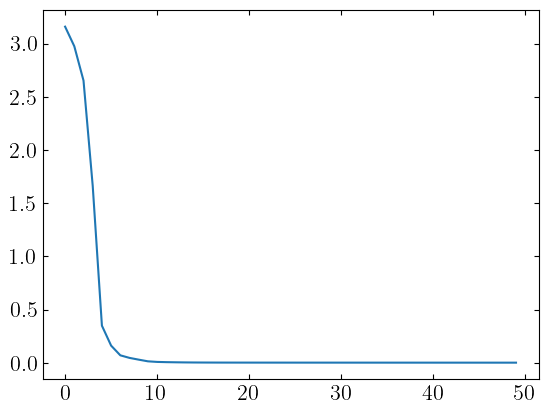

In [36]:
plt.plot(history['loss'])

Text(0, 0.5, 'Voltage [V]')

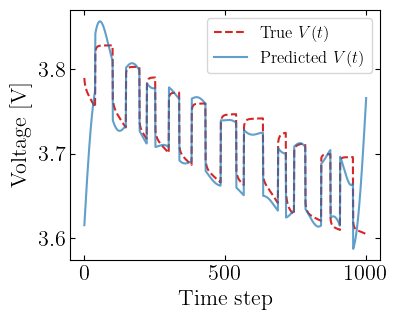

In [72]:
test = 12
i = I_test[test,0,:].reshape(1, 1, 1000) 
v = V_test[test,0,:].reshape(1, 1, 1000)

#print(i.shape, v.shape)
y_pred = model(torch.tensor(i, dtype=torch.float32)).detach().numpy()
#f, ax = plt.subplots(2,1,figsize=(9,6.5), gridspec_kw={'height_ratios': [.5, 1]}, sharex=True)


#f.subplots_adjust(hspace=0.05)
f, ax = plt.subplots(1,1,figsize=(4,3.25))
ax.plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
ax.plot(y_pred.ravel(), label='Predicted $V(t)$', color='tab:blue',alpha=0.7    )
ax.legend(fontsize = 12)
ax.set_xlabel('Time step')
ax.set_ylabel('Voltage [V]')
#f.savefig('NNN_figs/NNN_pred_small.pdf')

# ax[0].plot(i.ravel(), label='Input $I(t)$', color='black')
# ax[1].plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
# ax[1].plot(y_pred[0,0,:].detach().numpy(), label='Predicted $V(t)$', color='tab:blue')
# ax[1].legend()
# ax[0].legend()
# ax[1].set_xlabel('Time step')
# ax[0].set_ylabel('Current [A]')
# ax[1].set_ylabel('Voltage [V]')
#f.savefig('figs_NO/FNO_pred_mini.pdf', bbox_inches='tight')
#plt.show()




In [ ]:
T = 1000

u_test = np.zeros((1, 1,T))
y_test = np.zeros((1, 1,T))
w_test =  30# This is in the training range (0.5 to 2.0)

u_test[0,0,:] = np.sin(w_test * np.linspace(0, 3.14, T))  # w=1.5 is in the training range
y_test[0,0,:] = w_test * np.cos(w_test * np.linspace(0, 3.14, T))

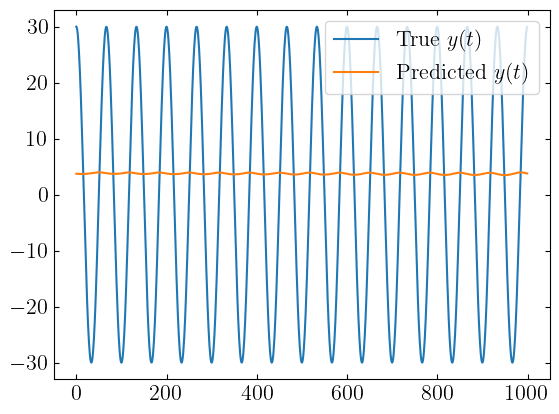

In [ ]:
y_pred = model(torch.tensor(u_test, dtype=torch.float32))
plt.plot(y_test[0,0,:], label='True $y(t)$')
plt.plot(y_pred[0,0,:].detach().numpy(), label='Predicted $y(t)$')
plt.legend()
plt.show()